# Series temporales de una cafetería

Ejercicio propuesto sobre el fichero `cafeteria_series_temporales_horarias.csv`.

## 0. Importar librerías y cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Opcional: mostrar todas las columnas al hacer display
pd.set_option("display.max_columns", None)

# Cargar datos
# Asegúrate de que el CSV está en la misma carpeta que este notebook
file_path = "cafeteria_series_temporales_horarias.csv"
df = pd.read_csv(file_path, parse_dates=["datetime"])

df.head()

,datetime,date,hour,day_of_week,is_weekend,is_vacation,time_band,sales
0,2024-01-01 00:00:00,2024-01-01,0,0,0,0,cerrado,4.0
1,2024-01-01 01:00:00,2024-01-01,1,0,0,0,cerrado,1.0
2,2024-01-01 02:00:00,2024-01-01,2,0,0,0,cerrado,5.0
3,2024-01-01 03:00:00,2024-01-01,3,0,0,0,cerrado,10.0
4,2024-01-01 04:00:00,2024-01-01,4,0,0,0,cerrado,1.0


## 1. Exploración inicial de los datos (apartado 4.1)

- Ver primeras filas
- Ver `info()` y `describe()`
- Responder a:
  - ¿Entre qué fechas va la serie?
  - ¿Cuál es la resolución temporal?  
  - ¿Hay valores nulos?

In [2]:
# Primeras filas
df.head()

,datetime,date,hour,day_of_week,is_weekend,is_vacation,time_band,sales
0,2024-01-01 00:00:00,2024-01-01,0,0,0,0,cerrado,4.0
1,2024-01-01 01:00:00,2024-01-01,1,0,0,0,cerrado,1.0
2,2024-01-01 02:00:00,2024-01-01,2,0,0,0,cerrado,5.0
3,2024-01-01 03:00:00,2024-01-01,3,0,0,0,cerrado,10.0
4,2024-01-01 04:00:00,2024-01-01,4,0,0,0,cerrado,1.0


In [5]:
# Información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     8784 non-null   datetime64[ns]
 1   date         8784 non-null   object        
 2   hour         8784 non-null   int64         
 3   day_of_week  8784 non-null   int64         
 4   is_weekend   8784 non-null   int64         
 5   is_vacation  8784 non-null   int64         
 6   time_band    8784 non-null   object        
 7   sales        8784 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 549.1+ KB


In [6]:
# Estadísticos básicos de las columnas numéricas
df.describe()

,datetime,hour,day_of_week,is_weekend,is_vacation,sales
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2024-07-01 23:30:00,11.500000,2.986339,0.284153,0.084699,28.608607
min,2024-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,-0.000000
25%,2024-04-01 11:45:00,5.750000,1.000000,0.000000,0.000000,15.000000
50%,2024-07-01 23:30:00,11.500000,3.000000,0.000000,0.000000,29.000000
75%,2024-10-01 11:15:00,17.250000,5.000000,1.000000,0.000000,41.000000
max,2024-12-31 23:00:00,23.000000,6.000000,1.000000,1.000000,81.000000
std,NaN,6.922581,2.003480,0.451036,0.278450,16.888583


In [7]:
# Fechas mínima y máxima
fecha_min = df["datetime"].min()
fecha_max = df["datetime"].max()
print("Fecha mínima:", fecha_min)
print("Fecha máxima:", fecha_max)

# Comprobación de valores nulos
print("\nValores nulos por columna:")
print(df.isna().sum())

Fecha mínima: 2024-01-01 00:00:00
Fecha máxima: 2024-12-31 23:00:00

Valores nulos por columna:
datetime       0
date           0
hour           0
day_of_week    0
is_weekend     0
is_vacation    0
time_band      0
sales          0
dtype: int64


## 2. Visualización de la serie horaria completa (apartado 4.2)

Representamos la serie completa hora a hora.

In [12]:
%matplotlib notebook   
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>


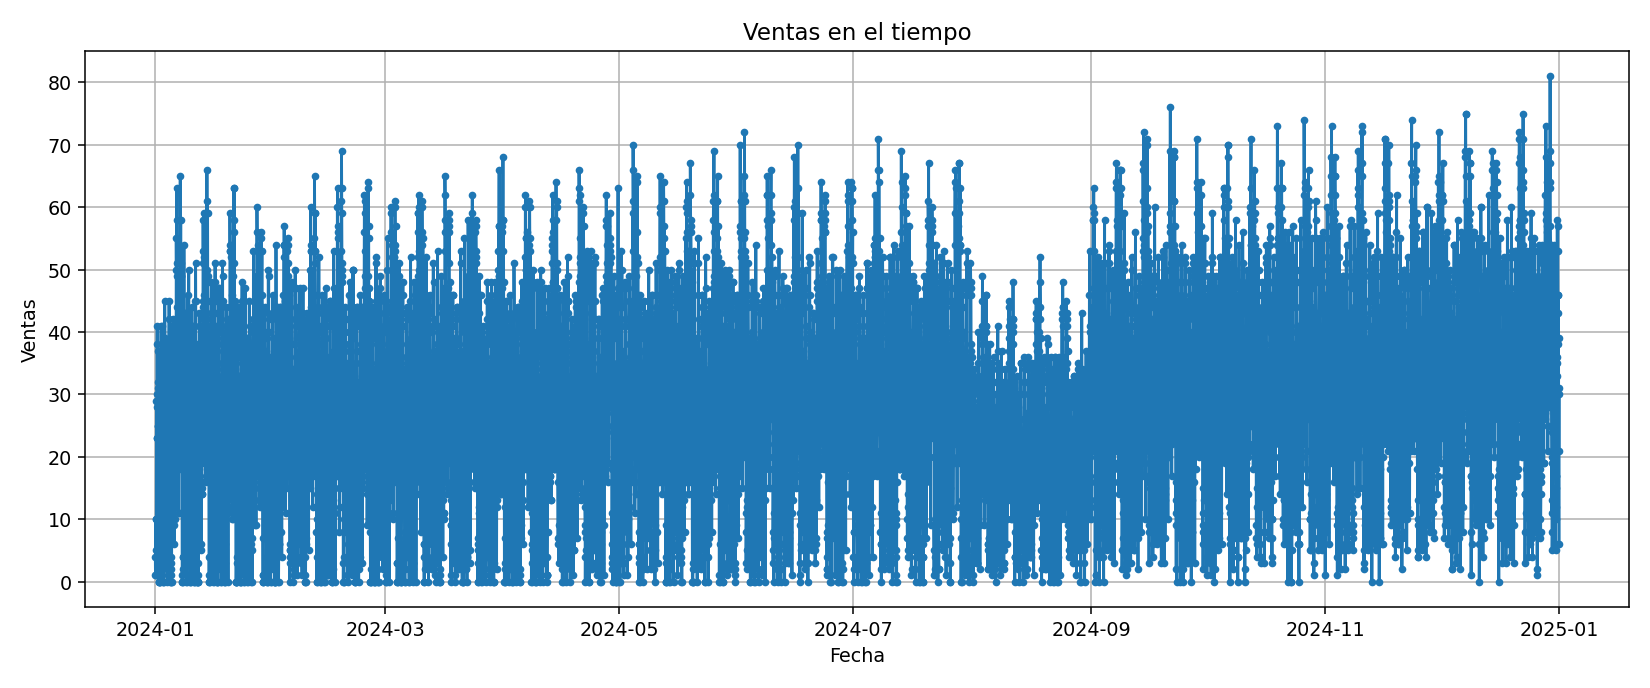

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["sales"], marker=".", linestyle="-")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Ventas en el tiempo")
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Estacionalidad por franja horaria (apartado 4.3)

Calculamos y visualizamos:

- Ventas medias por hora del día (0–23).
- Ventas medias por `time_band`.

In [15]:
# Media de ventas por hora del día
mean_by_hour = df.groupby("hour")["sales"].mean()
mean_by_hour

hour
0     11.142077
1     10.786885
2     11.243169
3     11.117486
4     11.008197
5     11.469945
6     10.912568
7     33.565574
8     33.371585
9     33.120219
10    32.907104
11    48.191257
12    48.516393
13    47.980874
14    48.254098
15    48.079235
16    38.150273
17    38.486339
18    38.240437
19    38.314208
20    23.797814
21    23.084699
22    23.415301
23    11.450820
Name: sales, dtype: float64

<IPython.core.display.Javascript object>


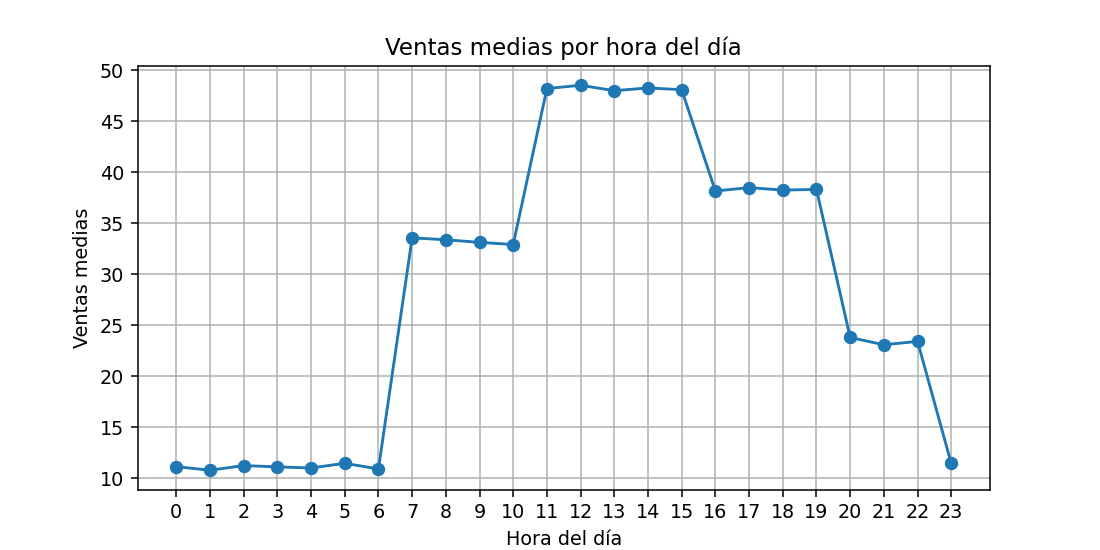

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(mean_by_hour.index, mean_by_hour.values, marker="o")
plt.title("Ventas medias por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Ventas medias")
plt.grid(True)
plt.xticks(range(0, 24))
#plt.tight_layout()
plt.show()

In [21]:
# Media de ventas por franja horaria (time_band)
mean_by_band = df.groupby("time_band")["sales"].mean().sort_values()
mean_by_band

time_band
cerrado     11.141393
noche       23.432605
mañana      33.241120
tarde       38.297814
mediodía    48.204372
Name: sales, dtype: float64

<IPython.core.display.Javascript object>


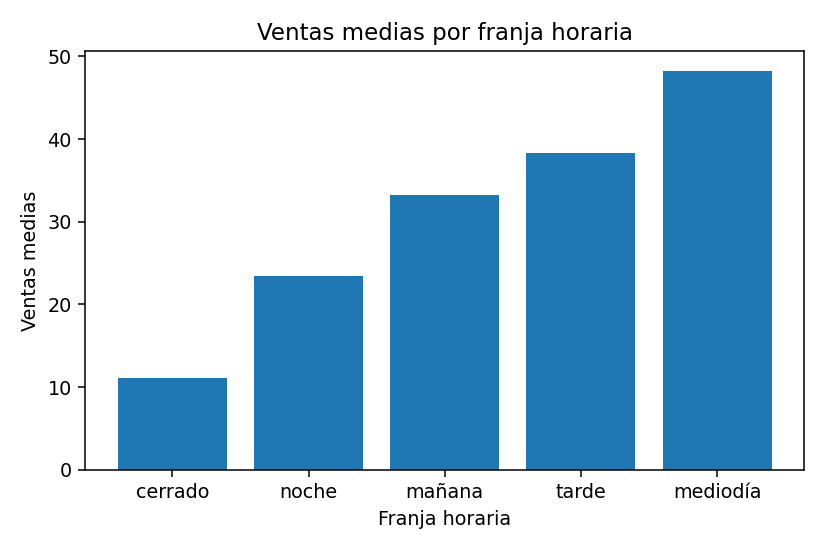

In [22]:
plt.figure(figsize=(6, 4))
plt.bar(mean_by_band.index, mean_by_band.values)
plt.title("Ventas medias por franja horaria")
plt.xlabel("Franja horaria")
plt.ylabel("Ventas medias")
plt.tight_layout()
plt.show()

## 4. Estacionalidad semanal (apartado 4.4)

Analizamos la media de ventas por día de la semana (0=lunes, ..., 6=domingo).

In [23]:
# Media de ventas por día de la semana
mean_by_dow = df.groupby("day_of_week")["sales"].mean()
mean_by_dow

day_of_week
0    24.486635
1    24.488208
2    24.576923
3    24.262821
4    24.607372
5    38.806891
6    39.189904
Name: sales, dtype: float64

<IPython.core.display.Javascript object>


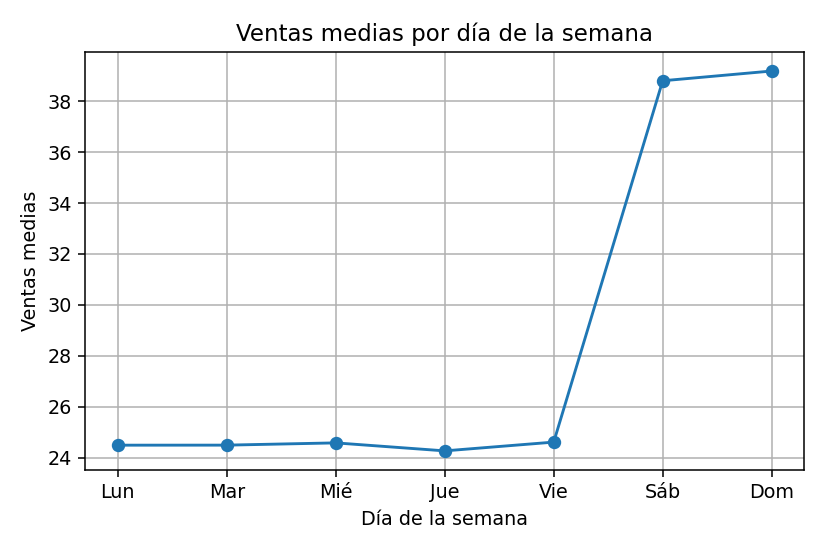

In [24]:
# Mapeo opcional de número de día -> nombre
dow_labels = {0: "Lun", 1: "Mar", 2: "Mié", 3: "Jue", 4: "Vie", 5: "Sáb", 6: "Dom"}

plt.figure(figsize=(6, 4))
plt.plot(mean_by_dow.index, mean_by_dow.values, marker="o")
plt.xticks(ticks=mean_by_dow.index, labels=[dow_labels[d] for d in mean_by_dow.index])
plt.title("Ventas medias por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Ventas medias")
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Efecto fin de semana y vacaciones (apartado 4.5)

Comparamos:

- Ventas medias diarias entre días laborables y fines de semana.
- Ventas medias diarias en agosto (vacaciones) frente al resto del año.

In [25]:
# Primero construimos una serie diaria sumando las ventas por día
daily = df.groupby("date").agg({
    "sales": "sum",
    "is_weekend": "max",   # si algún registro es fin de semana, el día se considera fin de semana
    "is_vacation": "max"   # idem para vacaciones
}).reset_index()

daily.head()

,date,sales,is_weekend,is_vacation
0,2024-01-01,468.0,0,0
1,2024-01-02,457.0,0,0
2,2024-01-03,505.0,0,0
3,2024-01-04,486.0,0,0
4,2024-01-05,494.0,0,0


In [26]:
# Media de ventas diarias en laborables vs fin de semana
mean_daily_weekday = daily.loc[daily["is_weekend"] == 0, "sales"].mean()
mean_daily_weekend = daily.loc[daily["is_weekend"] == 1, "sales"].mean()

print("Ventas diarias medias - Laborables:", round(mean_daily_weekday, 2))
print("Ventas diarias medias - Fines de semana:", round(mean_daily_weekend, 2))

Ventas diarias medias - Laborables: 587.63
Ventas diarias medias - Fines de semana: 935.96


In [27]:
# Media de ventas diarias en vacaciones (agosto) vs resto
mean_daily_vac = daily.loc[daily["is_vacation"] == 1, "sales"].mean()
mean_daily_non_vac = daily.loc[daily["is_vacation"] == 0, "sales"].mean()

print("Ventas diarias medias - Agosto (vacaciones):", round(mean_daily_vac, 2))
print("Ventas diarias medias - Resto del año:", round(mean_daily_non_vac, 2))

Ventas diarias medias - Agosto (vacaciones): 510.16
Ventas diarias medias - Resto del año: 702.93


## 6. Construcción y visualización de la serie diaria (apartado 4.6)

Usamos la serie diaria agregada para ver mejor tendencias y estacionalidad.

<IPython.core.display.Javascript object>


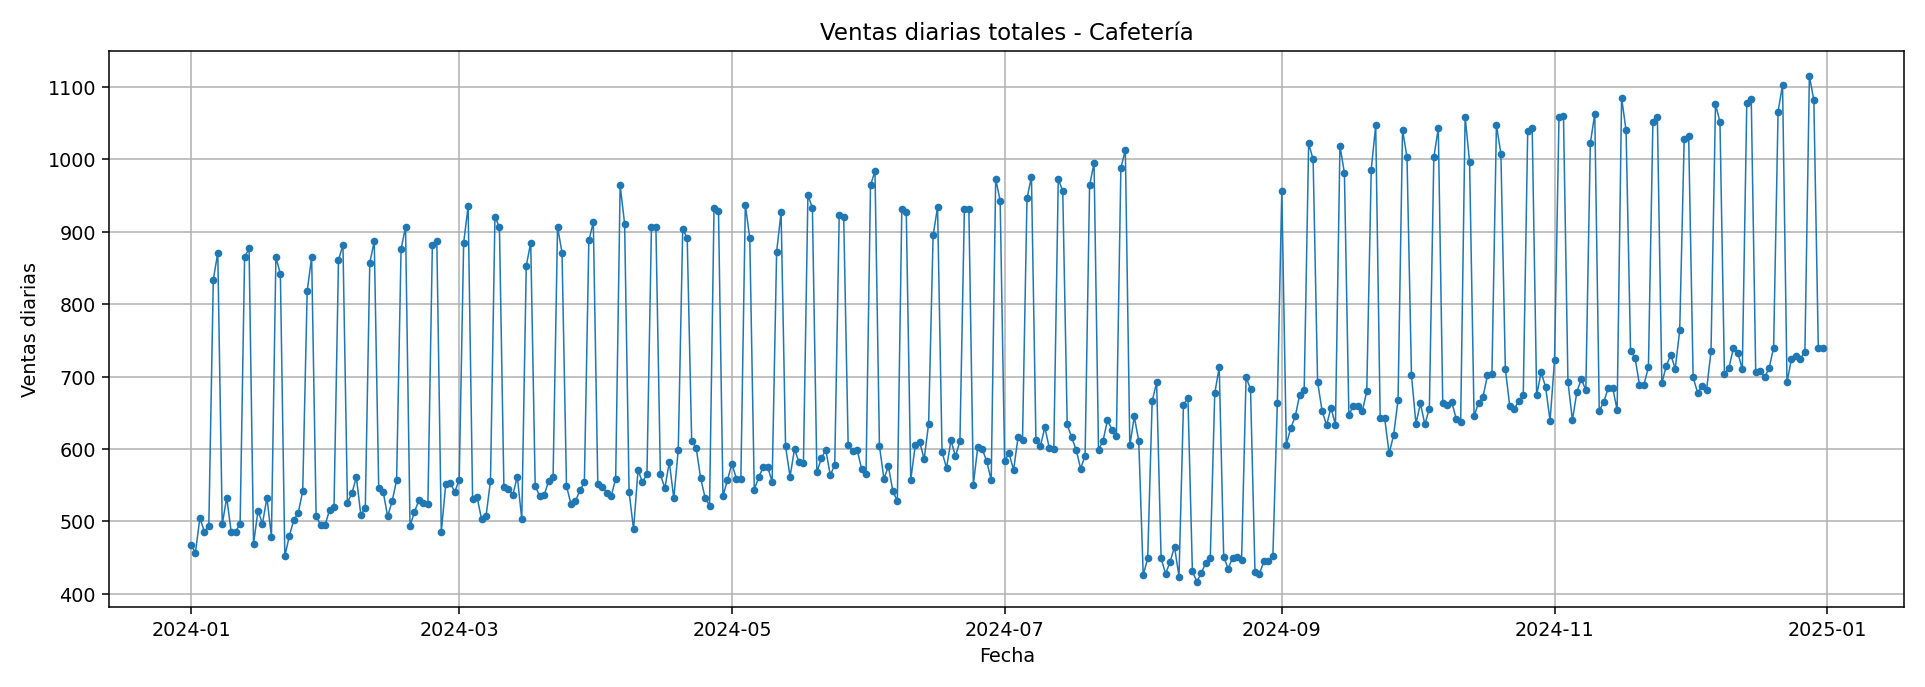

In [28]:
# Aseguramos que la columna date sea de tipo datetime.date o datetime64
daily["date"] = pd.to_datetime(daily["date"])

plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["sales"], marker=".", linestyle="-", linewidth=0.8)
plt.title("Ventas diarias totales - Cafetería")
plt.xlabel("Fecha")
plt.ylabel("Ventas diarias")
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Media móvil

Implementamos un modelo muy simple, basado en proxima predicción como la media móvil.



In [32]:
k = 3  # ventana

#media móvil de las 3 últimas filas(incluida la actual)
df["ma3"]  = df["sales"].rolling(k).mean()
#en la fila actual traigo el valor de 'ma3' de la fila anterior
df["pred"] = df['ma3'].shift(1)


<IPython.core.display.Javascript object>


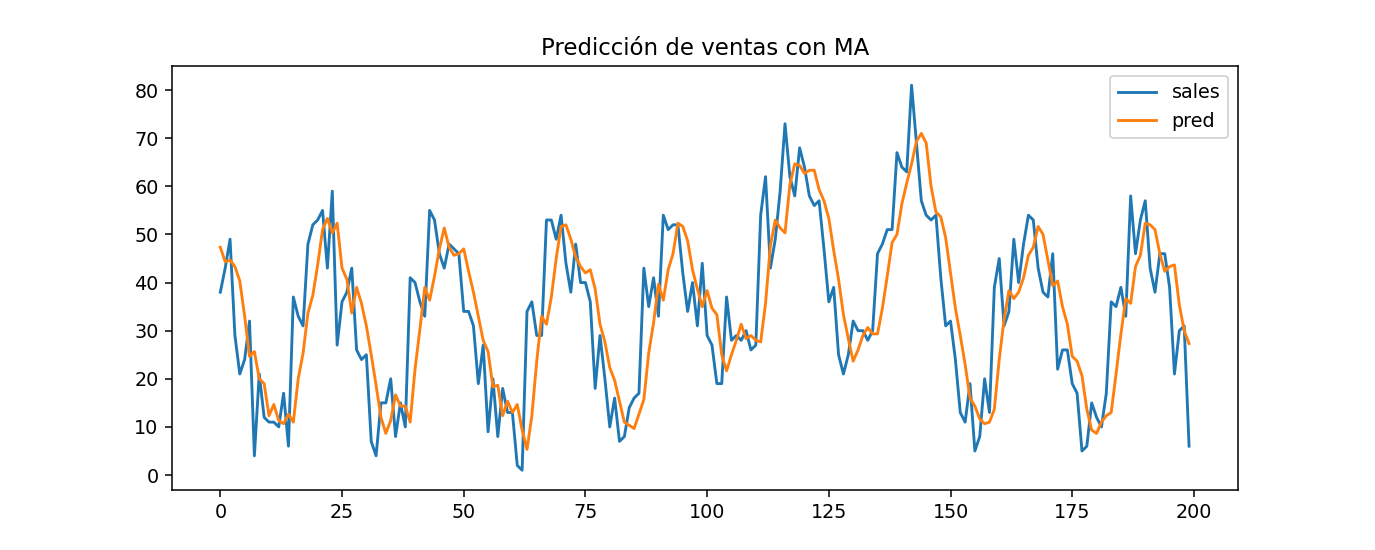

In [37]:
df_zoom = df.tail(200).reset_index()

cols = ["sales", "pred"]
df_zoom[cols].plot(figsize=(10,4))
plt.title("Predicción de ventas con MA")
plt.show()
